# Week 4 and 5: Actualizar la relacion M_BH-sigma con galaxias nuevas

Vamos a combinar 3 tablas.

La idea es juntar todo en una sola tabla `df_final` y luego re-graficar y re-fit.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## 1. Cargar la tabla original de McConnell & Ma (2013)

Esto ya lo hicimos en la Semana 2 — es lo mismo.

In [2]:
cols = ["Galaxy","Distance (Mpc)","MBH","MBH lower","MBH upper","method","sigma","sigma lower",
        "sigma upper","log(LV/Lsun)","error in log(LV/Lsun)","Mbulge/Msun",
        "radius of influence (arcsec)","Morphology","Profile"]

df_MM13 = pd.read_csv("McConnell_Ma_2013_ascii.txt", sep=r"\s+", names=cols, skiprows=17)
print(f"Galaxias en MM13: {len(df_MM13)}")
df_MM13.head()

Galaxias en MM13: 73


,Galaxy,Distance (Mpc),MBH,MBH lower,MBH upper,method,sigma,sigma lower,sigma upper,log(LV/Lsun),error in log(LV/Lsun),Mbulge/Msun,radius of influence (arcsec),Morphology,Profile
0,MW,0.008,4.100000e+06,3.500000e+06,4.700000e+06,star,103.0,83.0,123.0,0.00,0.00,0.000000e+00,43.00,S,NaN
1,A1836,157.500,3.900000e+09,3.300000e+09,4.300000e+09,gas,288.0,274.0,302.0,11.26,0.06,0.000000e+00,0.27,E,C
2,A3565,54.400,1.400000e+09,1.200000e+09,1.700000e+09,gas,322.0,306.0,338.0,11.24,0.06,0.000000e+00,0.22,E,C
3,Circ,4.000,1.700000e+06,1.400000e+06,2.100000e+06,maser,158.0,140.0,176.0,0.00,0.00,0.000000e+00,0.02,S,NaN
4,IC1459,30.900,2.800000e+09,1.600000e+09,3.900000e+09,star,315.0,299.0,331.0,10.96,0.06,3.070000e+11,0.81,E,C


## 2. Cargar la tabla de Liepold & Ma (2024)

Esta tabla tiene las masas nuevas de BH para galaxias del survey MASSIVE.  
El CSV (Libro1.csv) tiene columnas con nombres raros como ${M}_{K}^{2\mathrm{MASS}}$ que no nos interesan, asi que solo agarramos lo util: nombre, M_BH, metodo y referencia.


In [3]:
cols_liepold = ["Galaxy", "dist1", "dist2", "dist3", "MK_2MASS", "MK_CFHT",
                "M_BH", "Mstar_dyn", "Method", "Reference"]
df_liepold = pd.read_csv("Libro1.csv", names=cols_liepold, skiprows=1)

df_liepold = df_liepold[["Galaxy", "M_BH", "Method", "Reference"]].copy()

df_liepold = df_liepold.dropna(subset=["Galaxy"])

df_liepold

,Galaxy,M_BH,Method,Reference
0,NGC 57,NaN,Tri. stellar orbit,"J. Pilawa et al. 2024, in preparation"
1,NGC 315,2.02,CO gas,Boizelle et al. (2021)
2,NGC 708,8.98,Tri. stellar orbit,de Nicola et al. (2024)
3,NGC 997,3.28,CO gas,Dominiak et al. (2024)
4,NGC 1453,2.91,Tri. stellar orbit,Quenneville et al. (2022)
7,NGC 1600,19.05,Axi. stellar orbit,Thomas et al. (2016)
8,NGC 1684,1.40,CO gas,Dominiak et al. (2024)
9,NGC 2693,1.70,Tri. stellar orbit,Pilawa et al. (2022)
12,NGC 3842,8.63,Axi. stellar orbit,McConnell et al. (2011)
13,NGC 4472,2.44,Axi. stellar orbit,Rusli et al. (2013)


## 3. Cargar la tabla de Veale et al. (2017) con sigma nuevas

Esta tabla viene del paper del survey MASSIVE que mide velocidades de dispersion.  


In [4]:
cols_veale = ["Galaxy", "mk", "mstar", "lam", "sigc", "sigma",
              "gami", "gamo", "gamr", "h4avg", "h4grad",
              "env", "cluster", "mh", "delta", "nu"]
df_veale = pd.read_csv("table1.txt", sep=r"\s+", comment="#",
                        names=cols_veale, skiprows=1)

df_veale = df_veale[df_veale["Galaxy"] != "gal"].copy()

df_veale = df_veale[["Galaxy", "sigma"]].copy()

df_veale["sigma"] = pd.to_numeric(df_veale["sigma"], errors="coerce")

df_veale = df_veale.rename(columns={"sigma": "sigma_Veale"})

df_veale

,Galaxy,sigma_Veale
1,NGC0057,251
2,NGC0080,222
3,NGC0315,341
4,NGC0383,257
5,NGC0410,247
...,...,...
86,NGC7550,224
87,NGC7556,243
88,NGC7618,265
89,NGC7619,277


## 4. El problema de los nombres de galaxias

Cada tabla usa un formato distinto para los nombres
Si dejamos los nombres asi, pandas no puede juntar las tablas correctamente.  
Vamos a **normalizar** todos los nombres a un formato unico: `NGC4486`, `NGC57`, etc.

Lo hacemos con operaciones simples de texto (strings).

In [5]:
def normalizar_nombre(nombre):
    """Convierte cualquier formato de nombre a uno estandar: NGCxxxx (sin espacios ni ceros)."""
    if not isinstance(nombre, str):
        return nombre
    nombre = nombre.strip().upper()
    if nombre == "M87":
        return "NGC4486"

    # Si empieza con "N" solo (no NGC), convertirlo a NGC
    if nombre.startswith("N") and not nombre.startswith("NGC") and not nombre.startswith("NED"):
        numero = nombre[1:]  # todo despues de la N
        if numero.isdigit():
            return "NGC" + str(int(numero))  # int() le quita los ceros de adelante
    # Si empieza con NGC, sacarle el espacio y los ceros
    if nombre.startswith("NGC"):
        resto = nombre[3:].strip()  # todo despues de "NGC"
        if resto.isdigit():
            return "NGC" + str(int(resto))
    return nombre

In [6]:
df_MM13["Galaxy"]    = df_MM13["Galaxy"].apply(normalizar_nombre)
df_liepold["Galaxy"] = df_liepold["Galaxy"].apply(normalizar_nombre)
df_veale["Galaxy"]   = df_veale["Galaxy"].apply(normalizar_nombre)

In [7]:
df_MM13["Galaxy"].values


array(['MW', 'A1836', 'A3565', 'CIRC', 'IC1459', 'NGC221', 'NGC224',
       'NGC524', 'NGC821', 'NGC1023', 'NGC1194', 'NGC1300', 'NGC1316',
       'NGC1332', 'NGC1374', 'NGC1399', 'NGC1399', 'NGC1407', 'NGC1550',
       'NGC2273', 'NGC2549', 'NGC2787', 'NGC2960', 'NGC3031', 'NGC3091',
       'NGC3115', 'NGC3227', 'NGC3245', 'NGC3368', 'NGC3377', 'NGC3379',
       'NGC3384', 'NGC3393', 'NGC3489', 'NGC3585', 'NGC3607', 'NGC3608',
       'NGC3842', 'NGC3998', 'NGC4026', 'NGC4258', 'NGC4261', 'NGC4291',
       'NGC4342', 'NGC4374', 'NGC4388', 'NGC4459', 'NGC4472', 'NGC4473',
       'NGC4486', 'N4486A', 'NGC4564', 'NGC4594', 'NGC4596', 'NGC4649',
       'NGC4697', 'NGC4736', 'NGC4826', 'NGC4889', 'NGC5077', 'NGC5128',
       'NGC5516', 'NGC5576', 'NGC5845', 'NGC6086', 'NGC6251', 'NGC6264',
       'NGC6323', 'NGC7052', 'NGC7582', 'NGC7619', 'NGC7768', 'U3789'],
      dtype=object)

## 5. Preparar cada tabla antes de unirlas

Antes de juntar todo, renombramos las columnas para que se sepa de donde viene cada valor.  
 
Asi cuando las juntemos no se van a pisar.

In [9]:
df_MM13_clean = df_MM13[["Galaxy", "MBH", "MBH lower", "MBH upper",
                          "method", "sigma", "Morphology"]].copy()
df_MM13_clean = df_MM13_clean.rename(columns={"MBH":"M_BH_MM13","MBH lower":"M_BH_MM13_lower","MBH upper":"M_BH_MM13_upper","method":"Method_MM13",
    "sigma":"sigma_MM13","Morphology":"Morphology_MM13",
})
df_MM13_clean.head()

,Galaxy,M_BH_MM13,M_BH_MM13_lower,M_BH_MM13_upper,Method_MM13,sigma_MM13,Morphology_MM13
0,MW,4.100000e+06,3.500000e+06,4.700000e+06,star,103.0,S
1,A1836,3.900000e+09,3.300000e+09,4.300000e+09,gas,288.0,E
2,A3565,1.400000e+09,1.200000e+09,1.700000e+09,gas,322.0,E
3,CIRC,1.700000e+06,1.400000e+06,2.100000e+06,maser,158.0,S
4,IC1459,2.800000e+09,1.600000e+09,3.900000e+09,star,315.0,E


In [10]:
df_liepold_clean = df_liepold.rename(columns={
    "M_BH":     "M_BH_Liepold",
    "Method":   "Method_Liepold",
    "Reference": "Reference_Liepold",
})

# las masas de Liepold estan en unidades de 10^9 M_sun 
# Las pasamos a M_sun multiplicando por 1e9 para que coincidan con MM13
df_liepold_clean["M_BH_Liepold"] = df_liepold_clean["M_BH_Liepold"] * 1e9

df_liepold_clean

,Galaxy,M_BH_Liepold,Method_Liepold,Reference_Liepold
0,NGC57,NaN,Tri. stellar orbit,"J. Pilawa et al. 2024, in preparation"
1,NGC315,2.020000e+09,CO gas,Boizelle et al. (2021)
2,NGC708,8.980000e+09,Tri. stellar orbit,de Nicola et al. (2024)
3,NGC997,3.280000e+09,CO gas,Dominiak et al. (2024)
4,NGC1453,2.910000e+09,Tri. stellar orbit,Quenneville et al. (2022)
7,NGC1600,1.905000e+10,Axi. stellar orbit,Thomas et al. (2016)
8,NGC1684,1.400000e+09,CO gas,Dominiak et al. (2024)
9,NGC2693,1.700000e+09,Tri. stellar orbit,Pilawa et al. (2022)
12,NGC3842,8.630000e+09,Axi. stellar orbit,McConnell et al. (2011)
13,NGC4472,2.440000e+09,Axi. stellar orbit,Rusli et al. (2013)


## 6. Juntar (merge) las 3 tablas en una sola

merge busca filas donde el valor de "Galaxy" coincide y las une.  
how="outer" significa: "queda TODAS las galaxias, aunque no aparezcan en las 3 tablas".
Si una galaxia no esta en alguna tabla, esa celda queda como `NaN` (vacio).

In [11]:
# Primero juntamos MM13 con Liepold
df_final = df_MM13_clean.merge(df_liepold_clean, on="Galaxy", how="outer")

# Despues juntamos el resultado con Veale
df_final = df_final.merge(df_veale, on="Galaxy", how="outer")

df_final


,Galaxy,M_BH_MM13,M_BH_MM13_lower,M_BH_MM13_upper,Method_MM13,sigma_MM13,Morphology_MM13,M_BH_Liepold,Method_Liepold,Reference_Liepold,sigma_Veale
0,A1836,3.900000e+09,3.300000e+09,4.300000e+09,gas,288.0,E,NaN,NaN,NaN,NaN
1,A3565,1.400000e+09,1.200000e+09,1.700000e+09,gas,322.0,E,NaN,NaN,NaN,NaN
2,CIRC,1.700000e+06,1.400000e+06,2.100000e+06,maser,158.0,S,NaN,NaN,NaN,NaN
3,IC0310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0
4,IC1459,2.800000e+09,1.600000e+09,3.900000e+09,star,315.0,E,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
153,UGC01332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,253.0
154,UGC02783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,266.0
155,UGC03683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,257.0
156,UGC03894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,255.0


## 7. Crear las columnas finales que piden las instrucciones

Las instrucciones piden:
- `M_BH_MM13` y `M_BH_updated` (las dos masas, sin pisarse)
- `M_BH_reference` (de que paper salio el valor que usamos)
- `source_flag` (categoria: MM13_original / MM13_updated / LM24_new / extra_recent)
- `sigma_e` (sigma que vamos a graficar: usar Veale si hay, si no MM13)



In [12]:
set_liepold = set(df_liepold["Galaxy"])
set_veale   = set(df_veale["Galaxy"])

comunes = set_liepold & set_veale
print(f"Galaxias en Liepold:        {len(set_liepold)}")
print(f"Galaxias en Veale:          {len(set_veale)}")
print(f"En AMBOS:                   {len(comunes)}")
print(f"Solo en Liepold (sin σ):    {len(set_liepold - set_veale)}")
print()
print("Galaxias en Liepold que NO están en Veale:")
for g in sorted(set_liepold - set_veale):
    print(f"  {g}")

Galaxias en Liepold:        18
Galaxias en Veale:          90
En AMBOS:                   16
Solo en Liepold (sin σ):    2

Galaxias en Liepold que NO están en Veale:
  NGC4486
  NGC4649


In [13]:
set_MM13    = set(df_MM13["Galaxy"])
set_liepold = set(df_liepold["Galaxy"])
actualizadas = set_MM13 & set_liepold   
nuevas       = set_liepold - set_MM13   # solo en Liepold

print(f"actualizadas ={len(actualizadas)}")
print(f"Nuevas = {len(nuevas)}")
print(f"Total = {72 + len(nuevas)}")

actualizadas =7
Nuevas = 11
Total = 83


In [14]:
#Agregamos las columnas solicitadas
def asignar_flag(row):
    x = row['M_BH_MM13']
    y = row['M_BH_Liepold']
    z = row['sigma_Veale']
    if pd.notna(x) and pd.notna(y):
        return "MM13_updated"
    elif pd.notna(x) and pd.isna(y):
        return "MM13_original"
    elif pd.isna(x) and pd.notna(y):
        return "LM24_new"
    elif pd.isna(x) and pd.isna(y) and pd.notna(z):
        return "VP17_sigma"
    else:
        return np.nan 

def asignar_referencia(row):
    x = row['M_BH_MM13']
    y = row['M_BH_Liepold']
    z = row['sigma_Veale']
    if pd.notna(z) and pd.notna(y) and pd.isna(x):
        return "LM24_and_VP17"
    elif pd.notna(x) and pd.isna(y) and pd.isna(z):
        return "MM13"
    elif pd.isna(x) and pd.notna(y) and pd.isna(z):
        return "LM24"
    elif pd.isna(x) and pd.isna(y) and pd.notna(z):
        return "VP17"
    else:
        return np.nan 

df_final['Source_flag'] = df_final.apply(asignar_flag, axis=1)
df_final['References'] = df_final.apply(asignar_referencia, axis=1)
df_final

,Galaxy,M_BH_MM13,M_BH_MM13_lower,M_BH_MM13_upper,Method_MM13,sigma_MM13,Morphology_MM13,M_BH_Liepold,Method_Liepold,Reference_Liepold,sigma_Veale,Source_flag,References
0,A1836,3.900000e+09,3.300000e+09,4.300000e+09,gas,288.0,E,NaN,NaN,NaN,NaN,MM13_original,MM13
1,A3565,1.400000e+09,1.200000e+09,1.700000e+09,gas,322.0,E,NaN,NaN,NaN,NaN,MM13_original,MM13
2,CIRC,1.700000e+06,1.400000e+06,2.100000e+06,maser,158.0,S,NaN,NaN,NaN,NaN,MM13_original,MM13
3,IC0310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,VP17_sigma,VP17
4,IC1459,2.800000e+09,1.600000e+09,3.900000e+09,star,315.0,E,NaN,NaN,NaN,NaN,MM13_original,MM13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,UGC01332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,253.0,VP17_sigma,VP17
154,UGC02783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,266.0,VP17_sigma,VP17
155,UGC03683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,257.0,VP17_sigma,VP17
156,UGC03894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,255.0,VP17_sigma,VP17


In [21]:
df_extra_recent = pd.read_csv("extra_recent.csv", sep=",")
df_extra_recent

,Galaxy,MBH_extra_recent,MBH_upper_ER,MBH_lower_ER,sigma_ER,sigma_upper_ER,sigma_lower_ER,Source_flag,References
0,Holm 15A,4.000000e+10,4.800000e+10,3.200000e+10,346.0,359.0,334.0,extra_recent,Mehrgan et al. 2019
1,NGC315,3.000000e+09,3.300000e+09,2.700000e+09,NaN,NaN,NaN,extra_recent,Pilawa et al. 2025
2,4C+37.11,2.800000e+10,3.600000e+10,2.000000e+10,332.0,343.0,321.0,extra_recent,Surti et al. 2024
3,NGC708,1.000000e+10,1.280000e+10,7.200000e+09,250.0,NaN,NaN,extra_recent,de Nicola et al. 2024


In [ ]:
df_extra_recent

In [17]:
# Hacer el merge con extra_recent
# Renombramos Source_flag y References de extra_recent para evitar columnas _x/_y
df_extra_renamed = df_extra_recent.rename(columns={
    "Source_flag": "Source_flag_ER",
    "References":  "References_ER",
})

# how="outer" combina todas las galaxias. Si una galaxia está en ambas (NGC315, NGC708),
# sus datos se combinan en UNA sola fila (no se duplica)
df_final = df_final.merge(df_extra_renamed, on="Galaxy", how="outer")
df_final

,Galaxy,M_BH_MM13,M_BH_MM13_lower,M_BH_MM13_upper,Method_MM13,sigma_MM13,Morphology_MM13,M_BH_Liepold,Method_Liepold,Reference_Liepold,...,Source_flag,References,MBH_extra_recent,MBH_upper_ER,MBH_lower_ER,sigma_ER,sigma_upper_ER,sigma_lower_ER,Source_flag_ER,References_ER
0,4C+37.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.800000e+10,3.600000e+10,2.000000e+10,332.0,343.0,321.0,extra_recent,Surti et al. 2024
1,A1836,3.900000e+09,3.300000e+09,4.300000e+09,gas,288.0,E,NaN,NaN,NaN,...,MM13_original,MM13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A3565,1.400000e+09,1.200000e+09,1.700000e+09,gas,322.0,E,NaN,NaN,NaN,...,MM13_original,MM13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CIRC,1.700000e+06,1.400000e+06,2.100000e+06,maser,158.0,S,NaN,NaN,NaN,...,MM13_original,MM13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HOLM 15A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,4.000000e+10,4.800000e+10,3.200000e+10,346.0,359.0,334.0,extra_recent,Mehrgan et al. 2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,UGC01332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,VP17_sigma,VP17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
156,UGC02783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,VP17_sigma,VP17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
157,UGC03683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,VP17_sigma,VP17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,UGC03894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,VP17_sigma,VP17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df_master["M_BH_MM13"]=df_final["M_BH_MM13"]

NameError: name 'df_master' is not defined

## 9. Crear columnas combinadas MBH y sigma

Para plotear necesitamos una sola columna de M_BH y una sola de sigma por galaxia.
Prioridad (de más reciente a más viejo):
- **MBH**: extra_recent > Liepold > MM13
- **sigma**: Veale > MM13 (las extra_recent traen su propia sigma en `sigma_ER`)

Usamos `.fillna()` encadenado: "si este valor es NaN, usa el siguiente".

In [18]:
# Crear columna MBH combinada (prioridad: extra_recent > Liepold > MM13)
df_final["MBH"] = df_final["MBH_extra_recent"].fillna(df_final["M_BH_Liepold"]).fillna(df_final["M_BH_MM13"])

# Crear columna sigma combinada (prioridad: sigma_ER > Veale > MM13)
df_final["sigma"] = df_final["sigma_ER"].fillna(df_final["sigma_Veale"]).fillna(df_final["sigma_MM13"])

# Crear columna Source_flag unificada
# Si tiene Source_flag_ER (extra_recent), usar esa; si no, usar Source_flag
df_final["Source_flag_final"] = df_final["Source_flag_ER"].fillna(df_final["Source_flag"])

print("Columnas combinadas creadas: MBH, sigma, Source_flag_final")
print()
print("Distribución por Source_flag_final:")
print(df_final["Source_flag_final"].value_counts(dropna=False))

Columnas combinadas creadas: MBH, sigma, Source_flag_final

Distribución por Source_flag_final:
Source_flag_final
VP17_sigma       78
MM13_original    67
MM13_updated      6
LM24_new          5
extra_recent      4
Name: count, dtype: int64


## 10. Crear df_plot (solo galaxias ploteables)

Para el plot M-sigma necesitamos solo las galaxias que tienen **AMBOS** valores:
- `MBH` (combinada)
- `sigma` (combinada)

Usamos `dropna(subset=[...])` que significa "elimina las filas donde estas columnas sean NaN".

In [19]:
# Crear df_plot: solo las galaxias con MBH Y sigma (las que se pueden plotear)
# dropna(subset=[...]) elimina las filas donde las columnas indicadas sean NaN
df_plot = df_final.dropna(subset=["MBH", "sigma"]).copy()

# Reiniciar el índice para que los númeritos de la izquierda vayan 0,1,2,3,...
# (sin esto, conservan los índices originales de df_final y se ven saltados)
df_plot = df_plot.reset_index(drop=True)

print(f"Galaxias en df_plot: {len(df_plot)}")
print()
print("Distribución por Source_flag_final:")
print(df_plot["Source_flag_final"].value_counts(dropna=False))
df_plot[["Galaxy", "MBH", "sigma", "Source_flag_final"]].head(15)

Galaxias en df_plot: 82

Distribución por Source_flag_final:
Source_flag_final
MM13_original    67
MM13_updated      6
LM24_new          5
extra_recent      4
Name: count, dtype: int64


,Galaxy,MBH,sigma,Source_flag_final
0,4C+37.11,2.800000e+10,332.0,extra_recent
1,A1836,3.900000e+09,288.0,MM13_original
2,A3565,1.400000e+09,322.0,MM13_original
3,CIRC,1.700000e+06,158.0,MM13_original
4,HOLM 15A,4.000000e+10,346.0,extra_recent
5,IC1459,2.800000e+09,315.0,MM13_original
6,MW,4.100000e+06,103.0,MM13_original
7,N4486A,1.400000e+07,111.0,MM13_original
8,NGC1023,4.000000e+07,205.0,MM13_original
9,NGC1194,6.800000e+07,147.9,MM13_original


## 11. Plot M_BH vs sigma

Coloreamos por `Source_flag_final`:
- Azul claro: MM13 original
- Rojo: MM13 actualizada con Liepold
- Verde: galaxia nueva de Liepold (LM24_new)
- **Morado: extra_recent** (Holm 15A, 4C+37.11, NGC315 con Pilawa 2025, NGC708)

El fit se hace **solo con las galaxias más recientes** (extra_recent + LM24_new + MM13_updated),
como pide Silvana.

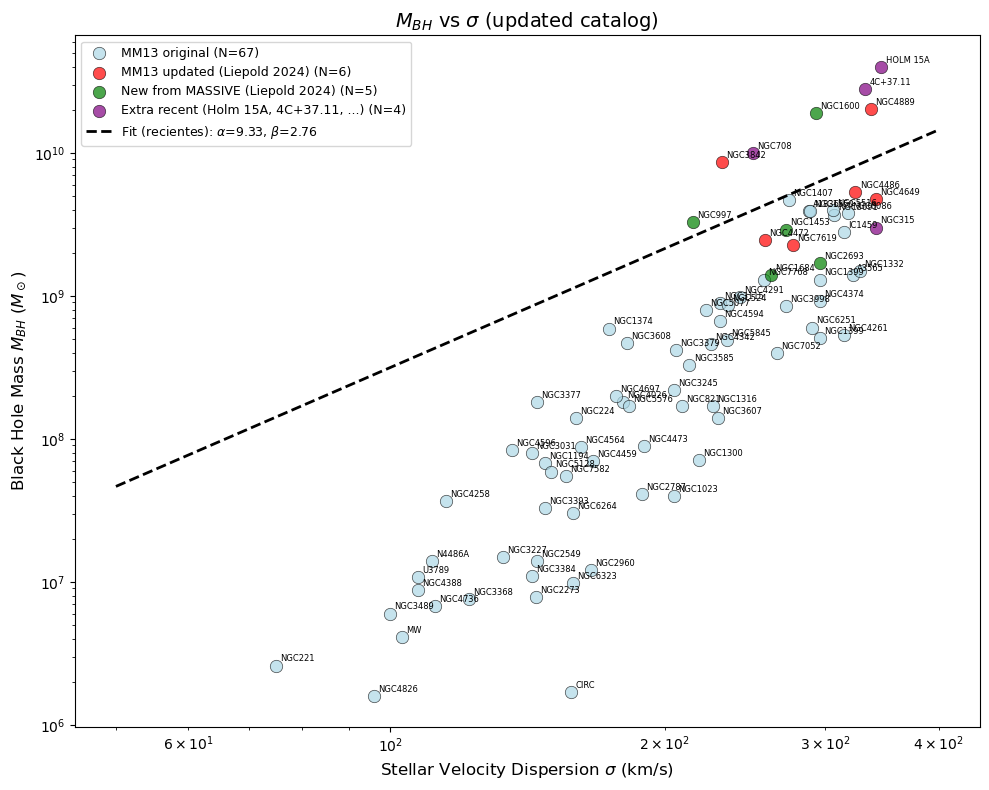

Fit con galaxias recientes (N=15):
  alpha = 9.330
  beta  = 2.762


In [20]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Stellar Velocity Dispersion $\sigma$ (km/s)", fontsize=12)
ax.set_ylabel("Black Hole Mass $M_{BH}$ ($M_\odot$)", fontsize=12)
ax.set_title("$M_{BH}$ vs $\sigma$ (updated catalog)", fontsize=14)

# Colores para cada categoría
colors = {
    "MM13_original": "lightblue",
    "MM13_updated":  "red",
    "LM24_new":      "green",
    "extra_recent":  "purple",
}
labels = {
    "MM13_original": "MM13 original",
    "MM13_updated":  "MM13 updated (Liepold 2024)",
    "LM24_new":      "New from MASSIVE (Liepold 2024)",
    "extra_recent":  "Extra recent (Holm 15A, 4C+37.11, ...)",
}

# Plotear cada categoría por separado
for flag in ["MM13_original", "MM13_updated", "LM24_new", "extra_recent"]:
    sub = df_plot[df_plot["Source_flag_final"] == flag]
    if len(sub) > 0:
        ax.scatter(sub["sigma"], sub["MBH"],
                   color=colors[flag], s=80, alpha=0.7,
                   edgecolors="black", linewidths=0.5,
                   label=f"{labels[flag]} (N={len(sub)})")

# Anotar nombres de galaxias
for i in range(len(df_plot)):
    row = df_plot.iloc[i]
    ax.annotate(row["Galaxy"],
                (row["sigma"], row["MBH"]),
                xytext=(3, 3), textcoords="offset points",
                fontsize=6)

# --- Fit solo con galaxias recientes ---
# (extra_recent + LM24_new + MM13_updated)
recientes = df_plot[df_plot["Source_flag_final"].isin(["extra_recent", "LM24_new", "MM13_updated"])]
logx = np.log10(recientes["sigma"] / 200.0)
logy = np.log10(recientes["MBH"])
beta, alpha = np.polyfit(logx, logy, 1)

# Dibujar línea del fit
sigma_grid = np.linspace(50, 400, 200)
x_grid = np.log10(sigma_grid / 200.0)
y_fit = alpha + beta * x_grid
ax.plot(sigma_grid, 10**y_fit, "k--", linewidth=2,
        label=f"Fit (recientes): $\\alpha$={alpha:.2f}, $\\beta$={beta:.2f}")

ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Fit con galaxias recientes (N={len(recientes)}):")
print(f"  alpha = {alpha:.3f}")
print(f"  beta  = {beta:.3f}")